In [7]:
import cv2
import matplotlib.pyplot as plt

In [2]:
import cv2

image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\lena5.jpg")

if image is None:
    raise FileNotFoundError("Could not read the image. Check the path and file format.")

print(type(image))  # <class 'numpy.ndarray'>
print(image.shape)  # (height, width, channels)

<class 'numpy.ndarray'>
(512, 512, 3)


In [6]:
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_saved.jpg", image)

True

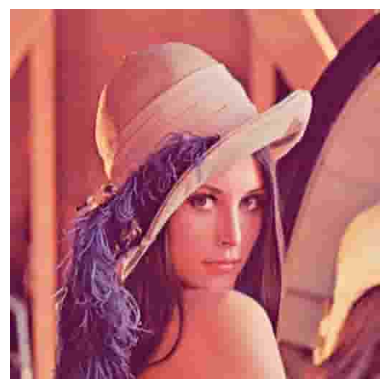

In [10]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.axis("off")
plt.show()


In [12]:
small = cv2.resize(image,(400,300))
crop = image[100:400,150:450]
horizontal = cv2.flip(image,1)
vertical = cv2.flip(image,0)
big = cv2.resize(image,(720,720))

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_small.jpg", small)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_crop.jpg", crop)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_horizontal.jpg", horizontal)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_vertical.jpg", vertical)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_big.jpg", big)

True

In [38]:
height, width = image.shape[:2]
center = (width-100, height-100)

matrix = cv2.getRotationMatrix2D(center,120,1.0)
rotated = cv2.warpAffine(
    image,
    matrix,
    (width,height)
)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_rotated.jpg", rotated)

True

In [39]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

print("Color:", image.shape)
print("Gray:", gray.shape)
print("HSV:", hsv.shape)


Color: (512, 512, 3)
Gray: (512, 512)
HSV: (512, 512, 3)


In [43]:
blur = cv2.blur(image, (5,5))
gaussian = cv2.GaussianBlur(image, (5,5),0)
median = cv2.medianBlur(image, 5)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_blur.jpg", blur)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_gaussian.jpg", gaussian)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\lena5_median.jpg", median)

True

In [48]:
noisy_image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\noisy_lena.webp")

median_clean = cv2.medianBlur(noisy_image, 5)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\noisy_lena_median_clean.jpg", median_clean)

True

In [50]:
import numpy as np

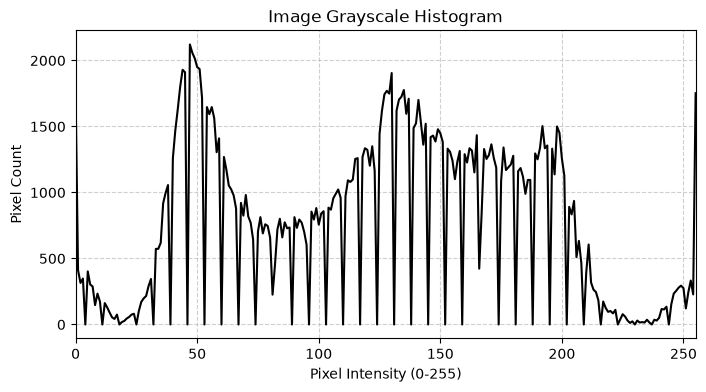

In [51]:
hist_noisy = np.bincount(noisy_image.ravel(), minlength=256).reshape(1, -1)

# Plot the histogram values as a line or bar chart
plt.figure(figsize=(8, 4))
plt.plot(hist_noisy[0], color="black")
plt.title("Image Grayscale Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Pixel Count")
plt.xlim([0, 255])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

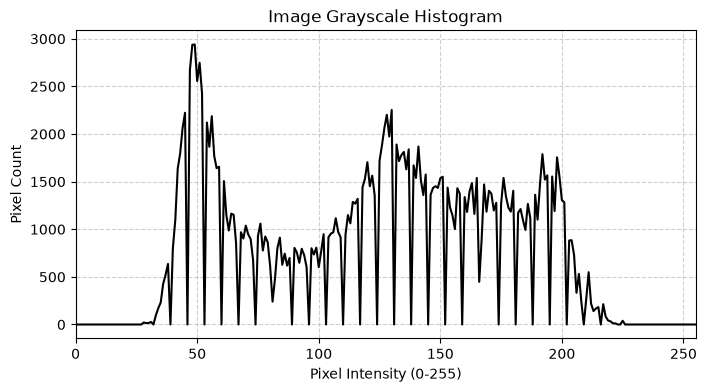

In [52]:
hist_clean = np.bincount(median_clean.ravel(), minlength=256).reshape(1, -1)

# Plot the histogram values as a line or bar chart
plt.figure(figsize=(8, 4))
plt.plot(hist_clean[0], color="black")
plt.title("Image Grayscale Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Pixel Count")
plt.xlim([0, 255])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [55]:
noisy_cam = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\noisy_camera_man.webp")
noisy_cam_pepper = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\paper_noisy_camera_man.webp")

median_cam = cv2.medianBlur(noisy_cam, 5)
median_cam_pepper = cv2.medianBlur(noisy_cam_pepper, 5)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\noisy_camera_man_clean.jpg", median_cam)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\paper_noisy_camera_man_clean.jpg", median_cam_pepper)

True

In [59]:
# Compute Laplacian (edges) using 64-bit float to handle negative values
laplacian = cv2.Laplacian(median_clean, cv2.CV_64F)
laplacian_cam = cv2.Laplacian(median_cam, cv2.CV_64F)
laplacian_cam_pepper = cv2.Laplacian(median_cam_pepper, cv2.CV_64F)

# Convert back to 8-bit unsigned integer
laplacian_8u = cv2.convertScaleAbs(laplacian)
laplacian_8u_cam = cv2.convertScaleAbs(laplacian_cam)
laplacian_8u_cam_pepper = cv2.convertScaleAbs(laplacian_cam_pepper)


# Subtract Laplacian from original to sharpen edges
sharpened = cv2.subtract(median_clean, laplacian_8u)
sharpened_cam = cv2.subtract(median_cam, laplacian_8u_cam)
sharpened_cam_pepper = cv2.subtract(median_cam_pepper, laplacian_8u_cam_pepper)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\noisy_lena_laplacian_sharp.jpg", sharpened)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\noisy_camera_man_laplacian_sharp.jpg", sharpened_cam)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\paper_noisy_camera_man_laplacian_sharp.jpg", sharpened_cam_pepper)

True